<a href="https://colab.research.google.com/github/uj-07/demo2/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [211]:
import numpy as np
import pandas as pd

In [212]:
df = pd.read_csv('/content/placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [213]:
df.shape

(100, 4)

In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

# PREPROCESS

In [241]:
df = df.iloc[:,1:]
# ALL THE ROWS
# ONE COLUMN REMOVED (0 INDEX UNNAMED) ALL THE COLUMN FROM INDEX 1

In [216]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


# EDA

In [217]:
import matplotlib.pyplot as plt

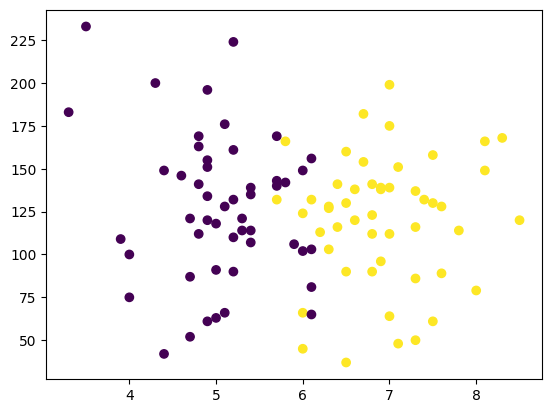

In [218]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])
# YELLOW = PLACED, PURPLE = NOT PLACED

#EXTRACTING INPUT AND OUTPUT

In [220]:
x = df.iloc[:,0:2] # INPUT
y = df.iloc[:,-1]  # OUTPUT

In [221]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [222]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


#TRAIN TEST SPLIT

In [223]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [224]:
x_train

,cgpa,iq
45,6.0,66.0
50,3.5,233.0
20,6.6,120.0
67,5.0,118.0
57,6.5,130.0
...,...,...
14,6.1,103.0
36,5.7,140.0
40,4.9,134.0
85,5.8,166.0


In [225]:
x_test

,cgpa,iq
86,5.1,128.0
47,5.2,161.0
21,7.1,151.0
92,5.2,110.0
80,4.9,196.0
76,4.9,155.0
39,4.6,146.0
53,8.3,168.0
31,3.9,109.0
27,6.0,124.0


In [226]:
y_test

,placement
86,0
47,0
21,1
92,0
80,0
76,0
39,0
53,1
31,0
27,1


In [227]:
y_train

,placement
45,1
50,0
20,1
67,0
57,1
...,...
14,0
36,0
40,0
85,1


#SCALING

In [228]:
from sklearn.preprocessing import StandardScaler

In [229]:
scaler = StandardScaler()

In [230]:
x_train = scaler.fit_transform(x_train)

In [231]:
x_train

array([[-0.03885517, -1.3702154 ],
       [-2.28049932,  2.77351447],
       [ 0.49913943, -0.0303267 ],
       [-0.93551283, -0.07995221],
       [ 0.40947367,  0.21780084],
       [-1.20451013, -0.00551395],
       [ 0.8578025 , -1.41984091],
       [ 1.21646556,  0.26742635],
       [ 1.39579709,  0.16817533],
       [-1.20451013, -0.84914757],
       [-0.93551283, -1.44465366],
       [ 0.67847096, -0.22882873],
       [-1.47350742, -1.96572149],
       [ 0.0508106 ,  0.86293244],
       [ 0.76813673, -0.62583279],
       [-0.30785246,  1.18549823],
       [-1.56317319,  1.9546936 ],
       [ 1.39579709, -0.79952206],
       [-0.03885517,  0.68924316],
       [ 0.23014213,  0.16817533],
       [-0.12852093, -0.37770525],
       [ 0.67847096, -0.77470931],
       [-0.84584706, -1.3702154 ],
       [ 2.20278899, -0.0303267 ],
       [ 0.5888052 ,  1.50806403],
       [ 0.3198079 , -0.12957771],
       [-0.30785246,  0.26742635],
       [-0.2181867 ,  0.51555388],
       [-1.83217049,

In [232]:
x_test = scaler.transform(x_test)
x_test

array([[-0.84584706,  0.16817533],
       [-0.75618129,  0.9869962 ],
       [ 0.94746826,  0.73886867],
       [-0.75618129, -0.27845424],
       [-1.02517859,  1.85544258],
       [-1.02517859,  0.83811968],
       [-1.29417589,  0.6148049 ],
       [ 2.02345746,  1.16068548],
       [-1.92183625, -0.30326699],
       [-0.03885517,  0.06892432]])

#TRAINING THE MODEL

In [233]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [234]:
clf.fit(x_train,y_train)

LogisticRegression()

PREDICTION

In [235]:
y_pred = clf.predict(x_test)


y_test

,placement
86,0
47,0
21,1
92,0
80,0
76,0
39,0
53,1
31,0
27,1


In [242]:
y_pred

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 1])

#EVALUATING

In [236]:
from sklearn.metrics import accuracy_score

In [237]:
accuracy_score(y_test,y_pred)

1.0

#VISUALIZING THE MODEL

<Axes: >

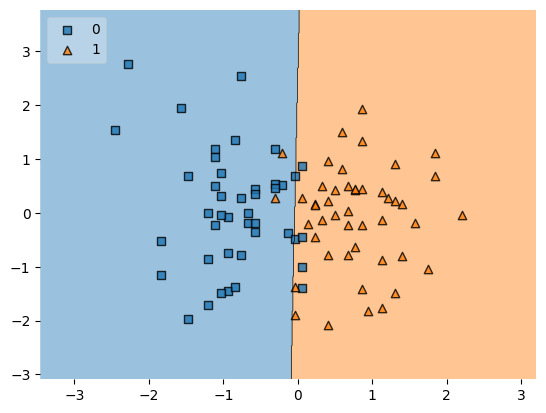

In [238]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

#DEPLOYING

In [239]:
import pickle

In [240]:
pickle.dump(clf,open('model.pkl','wb'))